In [1]:
WORK_DIR_PATH = ".."

In [2]:
SEED = 42

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.chdir(WORK_DIR_PATH)
print(f"DIRECTORY: {os.getcwd()}")

DIRECTORY: c:\Users\jayar\Desktop\바탕 화면\REPO\PROJECT\M1-PJT_ML


In [5]:
import sys
sys.path.append("src")

# Packages

In [ ]:
import pandas as pd
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Data

In [7]:
PATH = "./data/creditcard.csv"
origin = pd.read_csv(PATH)

In [8]:
DROP_COL = ["Time", "Amount"]
df = origin.drop(columns=DROP_COL)

In [9]:
df_normal = df[df["Class"]==0]
df_abnormal = df[df["Class"]==1]
df_normal_sampled = df_normal.sample(n=len(df_abnormal)*10, random_state=SEED)
df_sampled = pd.concat([df_normal_sampled, df_abnormal], ignore_index=True)

# t-SNE

In [10]:
X = df_sampled.drop(columns=['Class']).values
y = df_sampled['Class'].values

In [12]:
# t-SNE
kwargs = dict(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    max_iter=1000,
    random_state=SEED,
)

tsne = TSNE(**kwargs)

In [13]:
# transform
X_embedded = tsne.fit_transform(X)

Exception in thread Thread-5 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\jayar\anaconda3\Lib\threading.py", line 1038, in _bootstrap_inner
    self.run()
  File "C:\Users\jayar\AppData\Roaming\Python\Python311\site-packages\ipykernel\ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "c:\Users\jayar\anaconda3\Lib\threading.py", line 975, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\jayar\anaconda3\Lib\subprocess.py", line 1597, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xb8 in position 30: invalid start byte


In [14]:
# dataframe
df_tsne = pd.DataFrame(
    data=X_embedded, 
    columns=['TSNE1', 'TSNE2'],
)
df_tsne['y'] = y

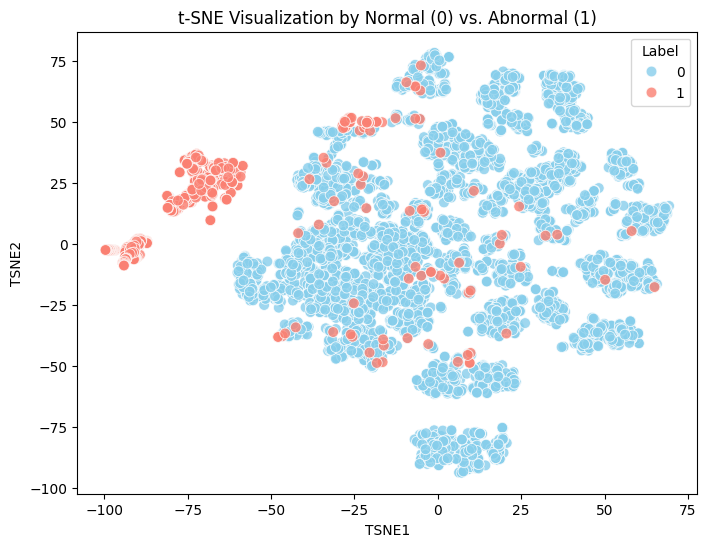

In [15]:
# visualization
kwargs = dict(
    data=df_tsne,
    x='TSNE1',
    y='TSNE2',
    hue='y',
    palette={0: 'skyblue', 1: 'salmon'},
    alpha=0.8,
    s=60,
)

plt.figure(figsize=(8,6))
sns.scatterplot(**kwargs)
plt.title('t-SNE Visualization by Normal (0) vs. Abnormal (1)')
plt.legend(title='Label')
plt.show()